## ADTA5560 Recurrent Neural Network Midterm
#### Question:
6.	PART IV: Simple RNN with Sine Wave Data and Keras (20 Points) 
TO-DO 
 
Build, train, and evaluate a simple recurrent neural network (a complete simple RNN) that has two layers: a SimpleRNN and a fully-connected layer in Keras. The SimpleRNN layer has 64 neurons. 
 
The training and testing the model are done on sine wave data belonging to a dataset generated by dividing the range 0 … 50 into 768 data points, including 0 and 50. All the tasks related to the project are done in Python using Jupyter Notebook. 

IMPORTANT NOTES: 
--) It is expected that the student knows how to count the layers of a deep neural network. 
 
--) First, draw a diagram to describe the architecture of the neural network with all the layers using MS PowerPoint or Draw Tool in MS Word. 
 
--) Build and train the model using the Keras sequential model in a Jupyter Notebook document. 
--) Run all the steps of the project in the Jupyter Notebook document to get the results of each step. 
 
 
 
IMPORTANT NOTES: 
--) It is expected that the student completes all the steps, including those related to data preprocessing. 
 
--) Evaluate the model on the test data. 
--) Write a report on these results. 


##  Importing Libraries

In [80]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [81]:
# for timeseries RNN neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [82]:
# import keras: TimeseriesGenerator
# this class produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# import keras: MinMax scalar
# this class is used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

# Generate Data 

In [83]:
# create a simple sine wave in numpy

#x = np.linspace(0,64,1024)
# range 0 … 50 into 768 data points
x = np.linspace(0,50,768)
y = np.sin(x)


In [84]:
x

array([ 0.        ,  0.06518905,  0.1303781 ,  0.19556714,  0.26075619,
        0.32594524,  0.39113429,  0.45632334,  0.52151239,  0.58670143,
        0.65189048,  0.71707953,  0.78226858,  0.84745763,  0.91264668,
        0.97783572,  1.04302477,  1.10821382,  1.17340287,  1.23859192,
        1.30378096,  1.36897001,  1.43415906,  1.49934811,  1.56453716,
        1.62972621,  1.69491525,  1.7601043 ,  1.82529335,  1.8904824 ,
        1.95567145,  2.0208605 ,  2.08604954,  2.15123859,  2.21642764,
        2.28161669,  2.34680574,  2.41199478,  2.47718383,  2.54237288,
        2.60756193,  2.67275098,  2.73794003,  2.80312907,  2.86831812,
        2.93350717,  2.99869622,  3.06388527,  3.12907432,  3.19426336,
        3.25945241,  3.32464146,  3.38983051,  3.45501956,  3.5202086 ,
        3.58539765,  3.6505867 ,  3.71577575,  3.7809648 ,  3.84615385,
        3.91134289,  3.97653194,  4.04172099,  4.10691004,  4.17209909,
        4.23728814,  4.30247718,  4.36766623,  4.43285528,  4.49

In [85]:
y

array([ 0.        ,  0.06514289,  0.13000904,  0.1943229 ,  0.25781126,
        0.3202044 ,  0.38123728,  0.44065063,  0.49819205,  0.55361709,
        0.60669031,  0.65718624,  0.70489037,  0.74960006,  0.79112536,
        0.82928988,  0.86393148,  0.89490301,  0.9220729 ,  0.94532572,
        0.9645627 ,  0.97970211,  0.99067964,  0.99744866,  0.99998041,
        0.99826414,  0.99230713,  0.98213469,  0.96779005,  0.94933412,
        0.92684533,  0.90041919,  0.87016798,  0.8362202 ,  0.79872006,
        0.75782688,  0.71371437,  0.66656992,  0.61659382,  0.56399835,
        0.50900696,  0.45185326,  0.39278003,  0.33203823,  0.2698859 ,
        0.20658706,  0.14241062,  0.0776292 ,  0.01251801, -0.05264636,
       -0.11758708, -0.18202829, -0.24569621, -0.30832039, -0.3696348 ,
       -0.42937895, -0.48729906, -0.54314907, -0.59669172, -0.64769957,
       -0.69595591, -0.74125576, -0.78340668, -0.8222296 , -0.8575596 ,
       -0.8892466 , -0.91715598, -0.94116918, -0.9611842 , -0.97

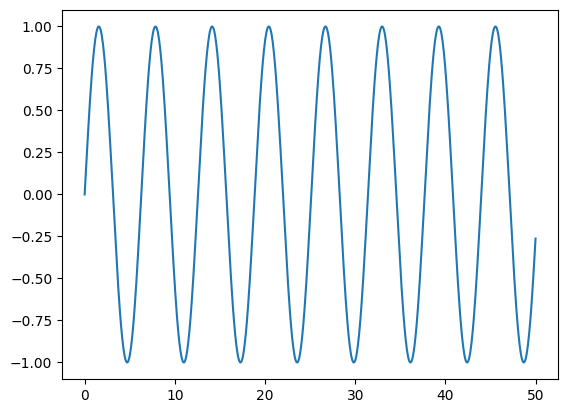

In [86]:
plt.plot(x, y)

In [87]:
# load data into a dataframe

df= pd.DataFrame(data=y, index=x, columns=['Sine'])
df.head(5)

,Sine
0.000000,0.000000
0.065189,0.065143
0.130378,0.130009
0.195567,0.194323
0.260756,0.257811


In [88]:
len(df)

768

# Split train and test data

In [89]:
# set percentage of data used for testing

test_percent=0.2

In [90]:
# Number of data points reserved for tesing the model
# 20% of the original dataset

len(df)*test_percent

153.60000000000002

In [91]:
# need to find the length (number of data points) of the testing dataset
# It has been found (above) that around 205 data points are used for testing 

test_length = np.round(len(df)*test_percent)
test_length 

154.0

In [92]:
# The testing dataset  starts at this index
# Index starting with 0

test_start_index = int(len(df) - test_length)

In [93]:
test_start_index

614

In [94]:
# Create separate training / testing datasets

# Training dataset: All the indices from start to the test_start_index 
# ( excluding the test_start_index)

data_train = df.iloc[: test_start_index]

# Testing dataset: all the indices from the test_start_index to the end of the dataframe
# (including test_start_index)

data_test= df.iloc[test_start_index :]

data_train.head(5)


,Sine
0.000000,0.000000
0.065189,0.065143
0.130378,0.130009
0.195567,0.194323
0.260756,0.257811


In [95]:
data_test.head(5)


,Sine
40.026076,0.727471
40.091265,0.681229
40.156454,0.632093
40.221643,0.580271
40.286832,0.525985


## Normalize the data ( scale it into [0,1])

In [96]:
# Create a MinMaxScalar to normalize the data
scalar = MinMaxScaler()

In [97]:
# IGNORE the warning: Just converting the data to floats
# Only Scale the Trainig data  - Not scale the testing data
# train the sccalar to perform the normalization

scalar.fit(data_train)

MinMaxScaler()

In [98]:
# Normalize the training dataset
normalized_train= scalar.transform(data_train)

# Normalize the testing dataset
normalized_train= scalar.transform(data_test)

# Create timeseries generator instance

In [99]:
#from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Set the length of the input sequence
# i.e., the number of time series steps used to predict the next one
# Use 50 historical data points to predict the next one
length = 50

# Set the batch size
# Number of time series samples in each batch
# Only one sample in each batch
batch_size = 1

# Create a TimeSeriesGenerator for training
# This time series generator produces time series batches used to train the model
# TimeseriesGenerator(inputs dataset, outputs dataset, length, batch_size)
train_tsGenerator50 = TimeseriesGenerator(normalized_train, normalized_train, length=length, batch_size=batch_size)

# Get the length of the normalized training data
len(normalized_train)


154

In [100]:
# first batch
X,y=train_tsGenerator50[0]


In [101]:
X.flatten()

array([8.63735291e-01, 8.40614095e-01, 8.16045927e-01, 7.90135155e-01,
       7.62991851e-01, 7.34731324e-01, 7.05473626e-01, 6.75343047e-01,
       6.44467586e-01, 6.12978404e-01, 5.81009272e-01, 5.48695997e-01,
       5.16175850e-01, 4.83586979e-01, 4.51067826e-01, 4.18756536e-01,
       3.86790370e-01, 3.55305125e-01, 3.24434552e-01, 2.94309793e-01,
       2.65058822e-01, 2.36805900e-01, 2.09671048e-01, 1.83769539e-01,
       1.59211403e-01, 1.36100968e-01, 1.14536408e-01, 9.46093322e-02,
       7.64043931e-02, 5.99989270e-02, 4.54626262e-02, 3.28572425e-02,
       2.22363247e-02, 1.36449918e-02, 7.11974059e-03, 2.68829111e-03,
       3.69468609e-04, 1.73123690e-04, 2.10009045e-03, 6.14218293e-03,
       1.22822299e-02, 2.04941477e-02, 3.07430514e-02, 4.29854023e-02,
       5.71691938e-02, 7.32341716e-02, 9.11120899e-02, 1.10727001e-01,
       1.31995580e-01, 1.54827474e-01])

In [102]:
y

array([[0.17912569]])

## Build Train and Test Model

# Build simple RNN Model

In [103]:
# Data set: Only one column/attribute: Sine values of index x
# Features: How many features used to train the model: Only one
n_features = 1

# define model
model = Sequential()

# Add a simple RNN layer: Using SimpleRNN cells
# This layer has 64 neurons: One neuron for each input data point
# NOTES: # time series steps of the input sequence: 50
model.add(SimpleRNN(64, input_shape=(length, n_features)))
#model.add(SimpleRNN(64))  # Second RNN layer

# Add a FC (fully-connected) layer for the final prediction
# Only one neuron of the Dense/Fully-Connected layer
# --> Output: Predict the next data point of the input sequence: only one value
model.add(Dense(1))


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# complie model

In [104]:
# complie the model

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

# Train (Fit) Model

In [105]:
# Fit the model
# Use fit_generator(), Not fit()

#model.fit_generator(train_tsGenerator50, epochs=5)
model.fit(train_tsGenerator50,epochs=5 )


Epoch 1/5
 27/104 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0522   

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0288
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9544e-04
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.5760e-04
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7418e-04
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0165e-04


# Visualize Model's Porformance After Training  

<Axes: >

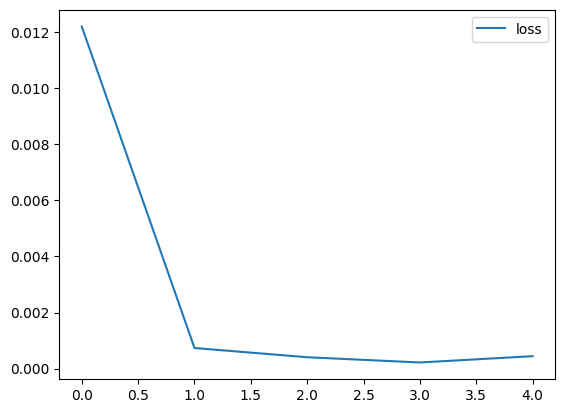

In [106]:
# load the loss data into a dataframe

df_model_loss = pd.DataFrame(model.history.history)

# visualize the loss data using Dataframe.plot()
df_model_loss.plot()


# Evaluate Model on Test Data

# A sneakpeak into the test data

In [107]:
length

50

In [108]:
first_eval_batch = normalized_train[-length : ]
first_eval_batch


array([[ 6.56405507e-01],
       [ 6.25136341e-01],
       [ 5.93335575e-01],
       [ 5.61138303e-01],
       [ 5.28681302e-01],
       [ 4.96102454e-01],
       [ 4.63540156e-01],
       [ 4.31132738e-01],
       [ 3.99017868e-01],
       [ 3.67331974e-01],
       [ 3.36209662e-01],
       [ 3.05783143e-01],
       [ 2.76181671e-01],
       [ 2.47530997e-01],
       [ 2.19952832e-01],
       [ 1.93564330e-01],
       [ 1.68477594e-01],
       [ 1.44799194e-01],
       [ 1.22629718e-01],
       [ 1.02063346e-01],
       [ 8.31874442e-02],
       [ 6.60822006e-02],
       [ 5.08202799e-02],
       [ 3.74665164e-02],
       [ 2.60776382e-02],
       [ 1.67020265e-02],
       [ 9.37950991e-03],
       [ 4.14119531e-03],
       [ 1.00933559e-03],
       [-2.76477259e-06],
       [ 1.10919374e-03],
       [ 4.34048740e-03],
       [ 9.67738934e-03],
       [ 1.70972278e-02],
       [ 2.65684826e-02],
       [ 3.80509187e-02],
       [ 5.14957575e-02],
       [ 6.68458840e-02],
       [ 8.4

In [109]:
first_eval_batch=first_eval_batch.reshape((1,length,n_features))

first_eval_batch

array([[[ 6.56405507e-01],
        [ 6.25136341e-01],
        [ 5.93335575e-01],
        [ 5.61138303e-01],
        [ 5.28681302e-01],
        [ 4.96102454e-01],
        [ 4.63540156e-01],
        [ 4.31132738e-01],
        [ 3.99017868e-01],
        [ 3.67331974e-01],
        [ 3.36209662e-01],
        [ 3.05783143e-01],
        [ 2.76181671e-01],
        [ 2.47530997e-01],
        [ 2.19952832e-01],
        [ 1.93564330e-01],
        [ 1.68477594e-01],
        [ 1.44799194e-01],
        [ 1.22629718e-01],
        [ 1.02063346e-01],
        [ 8.31874442e-02],
        [ 6.60822006e-02],
        [ 5.08202799e-02],
        [ 3.74665164e-02],
        [ 2.60776382e-02],
        [ 1.67020265e-02],
        [ 9.37950991e-03],
        [ 4.14119531e-03],
        [ 1.00933559e-03],
        [-2.76477259e-06],
        [ 1.10919374e-03],
        [ 4.34048740e-03],
        [ 9.67738934e-03],
        [ 1.70972278e-02],
        [ 2.65684826e-02],
        [ 3.80509187e-02],
        [ 5.14957575e-02],
 

In [110]:
first_eval_batch.shape


(1, 50, 1)

# Evaluate Model

In [111]:
# ALL the code for evaluation

# Declare a list to store all the predictions
# Similar to: test_predictions = list()
test_predictions = []

# Get the first time series batch for testing
# The 1st batch: The 1st time series input sequence
# = The last 50 data points of the train data set
first_eval_batch = normalized_train[-length:]

# Reshape the batch into 3D array: #samples/batch x Length x #features
current_batch = first_eval_batch.reshape((1, length, n_features))

# Run a FOR loop to make a prediction for each batch
for i in range(len(data_test)):

    # Get the value of the first element: The prediction
    current_pred = model.predict(current_batch)[0]

    # Store prediction into the list of predictions
    test_predictions.append(current_pred)

    # Generate a new batch to prepare for the next iteration of testing
    # --> Drop the first data point of the current input sequence
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

In [112]:
# convert the scaled result back to the real values
true_predictions= scalar.inverse_transform(test_predictions)

true_predictions

array([[-0.18469436],
       [-0.11567864],
       [-0.03962494],
       [ 0.03552385],
       [ 0.11491862],
       [ 0.19614527],
       [ 0.28243341],
       [ 0.36611182],
       [ 0.45281099],
       [ 0.53831498],
       [ 0.62071333],
       [ 0.70915736],
       [ 0.79230351],
       [ 0.87295116],
       [ 0.94737492],
       [ 1.01775035],
       [ 1.08459957],
       [ 1.1458827 ],
       [ 1.20132364],
       [ 1.25081391],
       [ 1.29306392],
       [ 1.32913294],
       [ 1.36218812],
       [ 1.38869946],
       [ 1.41129454],
       [ 1.42796352],
       [ 1.44124815],
       [ 1.4518904 ],
       [ 1.460323  ],
       [ 1.46501983],
       [ 1.46840179],
       [ 1.46873581],
       [ 1.46743905],
       [ 1.4656483 ],
       [ 1.4629475 ],
       [ 1.45877281],
       [ 1.45395463],
       [ 1.44796176],
       [ 1.44199798],
       [ 1.43623232],
       [ 1.42996098],
       [ 1.4236081 ],
       [ 1.41689068],
       [ 1.41013011],
       [ 1.40353333],
       [ 1

In [113]:
data_test

,Sine
40.026076,0.727471
40.091265,0.681229
40.156454,0.632093
40.221643,0.580271
40.286832,0.525985
...,...
49.739244,-0.502284
49.804433,-0.444888
49.869622,-0.385602
49.934811,-0.324678


In [114]:
# Copy the true values of predictions into the dataframe of original test data
# Add it as another column

data_test['Predictions'] = true_predictions

/var/tmp/ipykernel_4004/1664254025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test['Predictions'] = true_predictions


In [115]:
data_test

,Sine,Predictions
40.026076,0.727471,-0.184694
40.091265,0.681229,-0.115679
40.156454,0.632093,-0.039625
40.221643,0.580271,0.035524
40.286832,0.525985,0.114919
...,...,...
49.739244,-0.502284,1.109949
49.804433,-0.444888,1.108796
49.869622,-0.385602,1.107659
49.934811,-0.324678,1.106535


<Axes: >

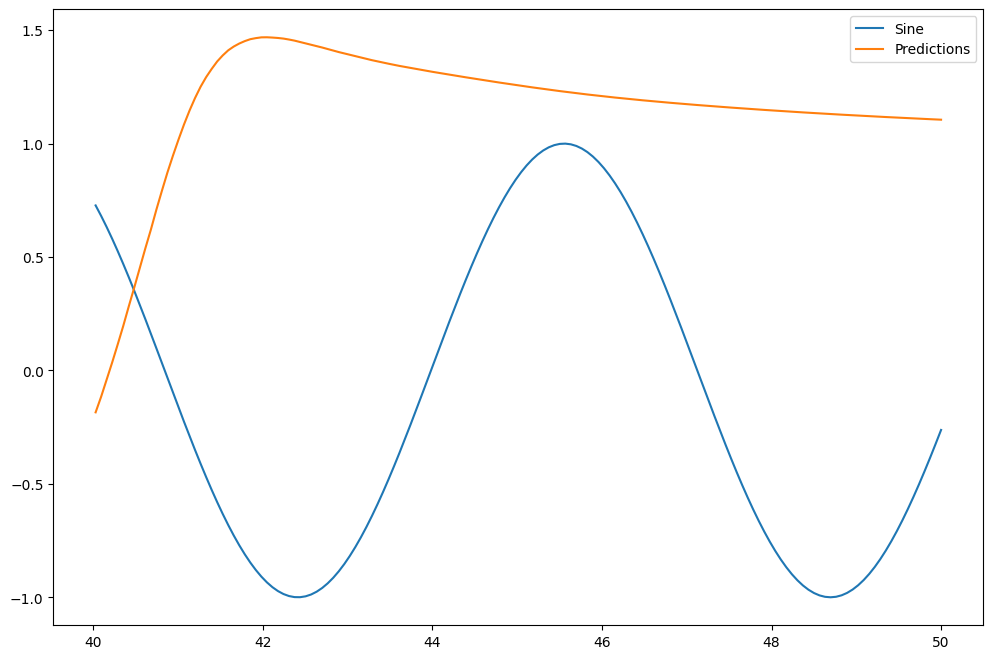

In [116]:
# visualize the updated data set
# Compare the predicted sine wave against the original sine wave

data_test.plot(figsize=(12,8))
